# Pipeline

In [38]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [39]:
#Load preprocessed data
df = pd.read_csv("Data/flightweather_encoded.csv", index_col=0)
print(df.info())
print(f"\nShape: {df.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 1851436 entries, 0 to 1851435
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Year             int64  
 1   Month            int64  
 2   Origin           int64  
 3   Dest             int64  
 4   DepDelayMinutes  float64
 5   ArrDelayMinutes  float64
 6   ArrDel15         float64
 7   windspeedKmph    int64  
 8   winddirDegree    int64  
 9   weatherCode      int64  
 10  precipMM         float64
 11  visibility       int64  
 12  pressure         int64  
 13  cloudcover       int64  
 14  DewPointF        int64  
 15  tempF            int64  
 16  humidity         int64  
dtypes: float64(4), int64(13)
memory usage: 240.1 MB
None

Shape: (1851436, 17)


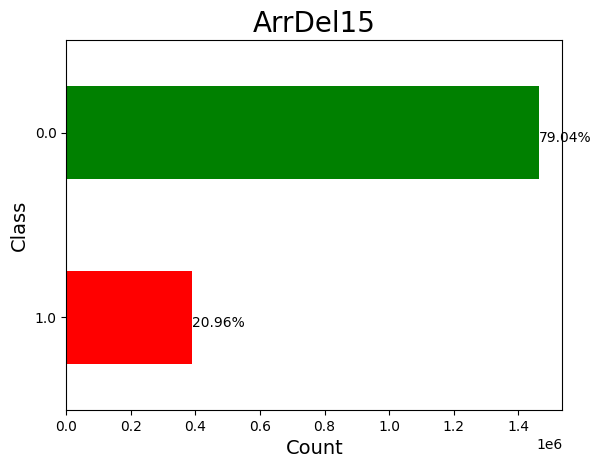

ArrDel15
0.0    1463378
1.0     388058
Name: count, dtype: int64


In [40]:
# Plotting the percentage of observations that fall under each class
ax = df["ArrDel15"].value_counts().sort_values().plot(kind="barh", color=["r", "g"])
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(df["ArrDel15"].value_counts())
fig = ax.get_figure()

# Classification

In [41]:
#sort features and labels

# features = df.loc[:, df.columns != "ArrDel15"]
# labels = np.asarray(df["ArrDel15"])
features = df.drop(columns = ['ArrDel15', 'ArrDelayMinutes'])
labels = df[["ArrDel15", "ArrDelayMinutes"]]
print(features.columns)

Index(['Year', 'Month', 'Origin', 'Dest', 'DepDelayMinutes', 'windspeedKmph',
       'winddirDegree', 'weatherCode', 'precipMM', 'visibility', 'pressure',
       'cloudcover', 'DewPointF', 'tempF', 'humidity'],
      dtype='str')


In [42]:
#train/test split


# print(f"\nDataset shape: {resampled_df.shape}")
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.20, random_state=42, stratify=labels["ArrDel15"])
print(f"features_train shape: {features_train.shape} | features_test shape: {features_test.shape}")
print(f"labels_train shape: {labels_train.shape} | labels_test shape: {labels_test.shape}")


# features_train.to_csv("Data/Pipeline2/features_train.csv")
# features_test.to_csv("Data/Pipeline2/features_test.csv")
# labels_train.to_csv("Data/Pipeline2/labels_train.csv", index=False)
# labels_test.to_csv("Data/Pipeline2/labels_test.csv", index=False)


# # pd.Series(labels_train, name="ArrDel15").to_csv("Data/Pipeline2/labels_train.csv", index=False)
# # pd.Series(labels_test,  name="ArrDel15").to_csv("Data/Pipeline2/labels_test.csv",  index=False)

features_train shape: (1481148, 15) | features_test shape: (370288, 15)
labels_train shape: (1481148, 2) | labels_test shape: (370288, 2)


In [43]:
#re-labeling features and labels as only clf with the labels only having ArrDel15

clf_features_train, clf_features_test = features_train, features_test
clf_labels_train, clf_labels_test = labels_train["ArrDel15"], labels_test["ArrDel15"]
print(f"clf_features_train shape: {clf_features_train.shape} | clf_features_test shape: {clf_features_test.shape}")
print(f"clf_labels_train shape: {clf_labels_train.shape} | clf_labels_test shape: {clf_labels_test.shape}")

clf_features_train shape: (1481148, 15) | clf_features_test shape: (370288, 15)
clf_labels_train shape: (1481148,) | clf_labels_test shape: (370288,)


In [44]:
# Dataset is resampled using SMOTE

smote = SMOTE(random_state=42)
clf_features_train, clf_labels_train = smote.fit_resample(clf_features_train, clf_labels_train)



# resampled_df = pd.DataFrame(features, columns=features.columns)
# resampled_df["ArrDel15"] = labels

#print(f"Resampled shape: {resampled_df.shape}")
#print(resampled_df["ArrDel15"].value_counts())
# resampled_df.to_csv("Data/Pipeline2/pipeline_smote.csv", index=False)

In [45]:
# #opening saved classification train and test data

# clf_features_train = pd.read_csv("Data/Pipeline2/clf_features_train.csv", index_col=0)
# clf_features_test  = pd.read_csv("Data/Pipeline2/clf_features_test.csv",  index_col=0)
# clf_labels_train   = pd.read_csv("Data/Pipeline2/clf_labels_train.csv")
# clf_labels_test    = pd.read_csv("Data/Pipeline2/clf_labels_test.csv")


In [46]:
# filepath = "Data/flightweather_smote.csv"
# resampled_df = pd.read_csv(filepath, index_col=0)

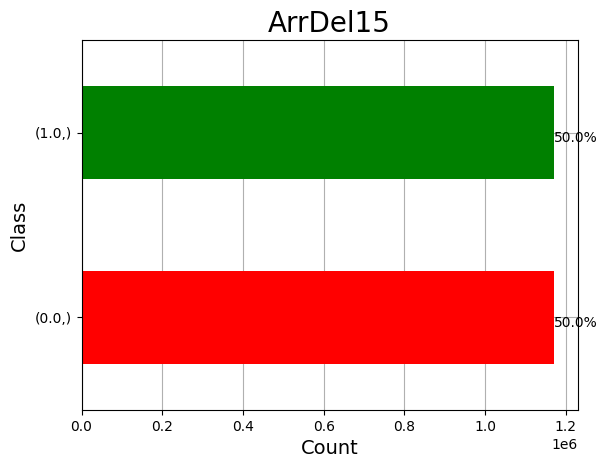

ArrDel15
0.0         1170702
1.0         1170702
Name: count, dtype: int64


In [47]:
#Class Distribution

ax = pd.DataFrame(clf_labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(pd.DataFrame(clf_labels_train).value_counts())
fig = ax.get_figure()

              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94    292676
         1.0       0.77      0.76      0.77     77612

    accuracy                           0.90    370288
   macro avg       0.86      0.85      0.85    370288
weighted avg       0.90      0.90      0.90    370288



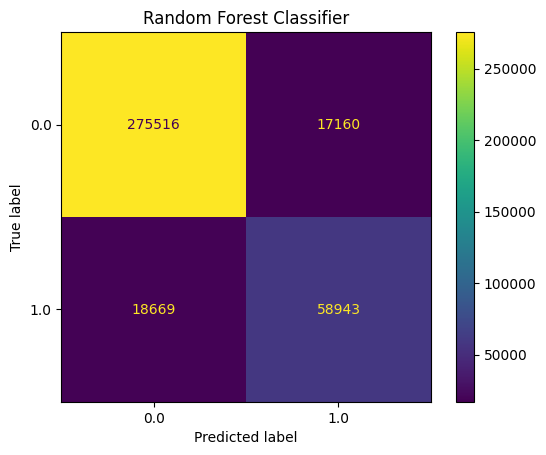

In [48]:
#Random Forest

model = RandomForestClassifier(n_jobs=-1, random_state=42)
model.fit(clf_features_train, clf_labels_train)
joblib.dump(model, "Data/Pipeline2/RandomForestClassifier.joblib")
model = joblib.load("Data/Pipeline2/RandomForestClassifier.joblib")
model_pred = model.predict(clf_features_test)
print(classification_report(clf_labels_test, model_pred))
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, clf_features_test, clf_labels_test)
plt.title("Random Forest Classifier")
plt.show()

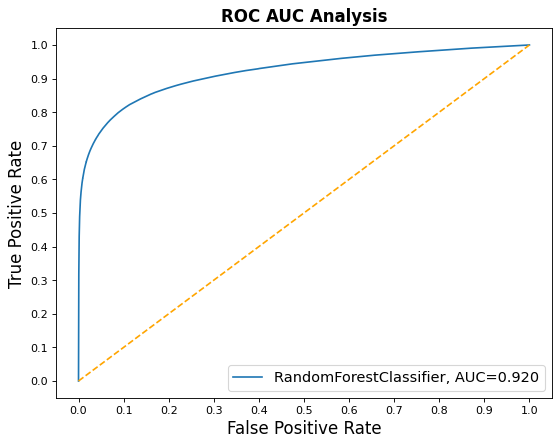

In [49]:
#ROC AUC Analysis

rows = []

classifiers = ["RandomForestClassifier"]
for clf in classifiers:
    model2 = joblib.load(f"./Data/Pipeline2/{clf}.joblib")
    model_pred2 = model2.predict_proba(clf_features_test)[:, 1]
    fpr, tpr, _ = roc_curve(clf_labels_test, model_pred2)
    auc = roc_auc_score(clf_labels_test, model_pred2)
    rows.append({"classifiers": clf,
                 "fpr": fpr,
                 "tpr": tpr,
                 "auc": auc})
    del model2
    del model_pred2

perf_df = pd.DataFrame(rows, columns=["classifiers", "fpr", "tpr", "auc"])
perf_df.set_index("classifiers", inplace=True)

fig = plt.figure(figsize=(8,6), dpi=80)
for clf_name in perf_df.index:
    plt.plot(perf_df.loc[clf_name]["fpr"], 
             perf_df.loc[clf_name]["tpr"], 
             label="{}, AUC={:.3f}".format(clf_name, perf_df.loc[clf_name]["auc"]))
    
plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)

plt.title("ROC AUC Analysis", fontweight="bold", fontsize=15)
plt.legend(prop={"size":13}, loc="lower right")

plt.show()

# Regression

In [50]:
# #take only features of data points where classification model predicts there to be a delay

# del_features = features_test
# del_features["Predicted_ArrDel15"] = model_pred
# del_features = del_features.loc[:][del_features["Predicted_ArrDel15"] == 1.0]
# del_features = del_features.drop(["Predicted_ArrDel15"], axis=1)

In [51]:
# #take only labels of data points where classification model predicts there to be a delay

# del_labels = pd.DataFrame(labels_test["ArrDelayMinutes"])
# del_labels["Predicted_ArrDel15"] = model_pred
# del_labels = del_labels.loc[:][del_labels["Predicted_ArrDel15"] == 1.0]
# del_labels = del_labels.drop(["Predicted_ArrDel15"], axis=1)
# del_labels = np.asarray(del_labels["ArrDelayMinutes"])

In [52]:
# del_features.shape, del_labels.shape

In [53]:
# # print(f"\nDataset shape: {resampled_df.shape}")
# reg_features_train, reg_features_test, reg_labels_train, reg_labels_test = train_test_split(del_features, del_labels, test_size=0.20, random_state=42)
# print(f"reg_features_train shape: {reg_features_train.shape} | reg_features_test shape: {reg_features_test.shape}")
# print(f"reg_labels_train shape: {reg_labels_train.shape} | reg_labels_test shape: {reg_labels_test.shape}")

# reg_features_train.to_csv("Data/Pipeline2/reg_features_train.csv")
# reg_features_test.to_csv("Data/Pipeline2/reg_features_test.csv")
# pd.Series(reg_labels_train, name="ArrDelayMinutes").to_csv("Data/Pipeline2/reg_labels_train.csv", index=False)
# pd.Series(reg_labels_test,  name="ArrDelayMinutes").to_csv("Data/Pipeline2/reg_labels_test.csv",  index=False)

In [54]:
# # #opening saved regression train and test data

# reg_features_train = pd.read_csv("Data/Pipeline2/reg_features_train.csv", index_col=0)
# reg_features_test  = pd.read_csv("Data/Pipeline2/reg_features_test.csv",  index_col=0)
# reg_labels_train   = pd.read_csv("Data/Pipeline2/reg_labels_train.csv")["ArrDelayMinutes"].to_numpy()
# reg_labels_test    = pd.read_csv("Data/Pipeline2/reg_labels_test.csv")["ArrDelayMinutes"].to_numpy()

In [55]:
# ----- Stage 2 TRAINING data: truly-delayed flights from the TRAINING partition -----
# Use the ORIGINAL (non-SMOTE) training partition so the delay minutes are real,
# not synthetic interpolations. features_train is untouched by the SMOTE in cell 8
# because cell 8 rebinds clf_features_train to a new object.
train_delayed_mask = labels_train["ArrDel15"] == 1.0

reg_features_train = features_train.loc[train_delayed_mask].copy()
reg_labels_train   = labels_train.loc[train_delayed_mask, "ArrDelayMinutes"].to_numpy()

print(f"reg_features_train shape: {reg_features_train.shape}")
print(f"reg_labels_train shape:   {reg_labels_train.shape}")

reg_features_train shape: (310446, 15)
reg_labels_train shape:   (310446,)


In [56]:
pred_delayed_mask = (model_pred == 1.0)

reg_features_test = features_test.loc[pred_delayed_mask].copy()
reg_labels_test   = labels_test.loc[pred_delayed_mask, "ArrDelayMinutes"].to_numpy()

print(f"reg_features_test shape: {reg_features_test.shape}")
print(f"reg_labels_test shape:   {reg_labels_test.shape}")

reg_features_test shape: (76103, 15)
reg_labels_test shape:   (76103,)


In [57]:
# print(f"reg_features_train shape: {reg_features_train.shape} | reg_features_test shape: {reg_features_test.shape}")
# print(f"reg_labels_train shape: {reg_labels_train.shape} | reg_labels_test shape: {reg_labels_test.shape}")

In [58]:
#setting up function and dataframe for computing metrics

perf_df = pd.DataFrame(columns=["Regressors", "MSE", "RMSE", "MAE", "R2"])
def print_metrics(reg_labels_test, model_pred, regressor_name, perf_df):
    
    mse = mean_squared_error(reg_labels_test, model_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(reg_labels_test, model_pred)
    r2 = r2_score(reg_labels_test, model_pred)
    
    print(f"MSE      : {mse}", end="\n\n")
    print(f"RMSE     : {rmse}", end="\n\n")
    print(f"MAE      : {mae}", end="\n\n")
    print(f"R2 Score : {r2}", end="\n\n")
    
    new_row = pd.DataFrame([{
        "Regressors": regressor_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    }])
    perf_df = pd.concat([perf_df, new_row], ignore_index=True)
    return perf_df

In [59]:
#Extra Trees

model = ExtraTreesRegressor(n_jobs=-1, random_state=42)
model.fit(reg_features_train, reg_labels_train)
joblib.dump(model, "Data/Pipeline2/ExtraTreesRegressor.joblib")
model = joblib.load("Data/Pipeline2/ExtraTreesRegressor.joblib")
model_pred = model.predict(reg_features_test)
perf_df = print_metrics(reg_labels_test, model_pred, "ExtraTreesRegressor", perf_df)

MSE      : 394.99491088642475

RMSE     : 19.87447888339276

MAE      : 15.198611585614234

R2 Score : 0.9291429711750245



# Bin Count

In [60]:
#predicted_delays = model.predict(reg_features_test)

In [61]:
reg_features_test["ArrDelayMinutes"] = pd.DataFrame(reg_labels_test)[0].values

In [62]:
print("Min: ", reg_features_test["ArrDelayMinutes"].min())
print("Max: ", reg_features_test["ArrDelayMinutes"].max())

Min:  0.0
Max:  2028.0


In [63]:
# # Bin count of PREDICTED arrival delay minutes
# bins   = [0, 15, 30, 60, 120, 180, np.inf]
# labels = ["0–15", "15–30", "30–60", "60–120", "120–180", "180+"]

# pred_bins = pd.cut(pd.Series(predicted_delays), bins=bins, labels=labels, right=False)

# pred_counts = pred_bins.value_counts().sort_index()
# print(pred_counts)
# print(f"\nTotal: {pred_counts.sum()}")

# ax = pred_counts.plot(kind="bar", color="darkorange")
# ax.set_axisbelow(True)
# ax.grid(axis="y")
# total = pred_counts.sum()
# for p in ax.patches:
#     ax.text(p.get_x() + p.get_width()/2, p.get_height(),
#             f"{round(p.get_height()/total*100, 2)}%",
#             ha="center", va="bottom", fontsize=9)
# plt.title("Predicted ArrDelayMinutes — Binned Count", fontsize=16)
# plt.xlabel("Delay (minutes)", fontsize=12)
# plt.ylabel("Count", fontsize=12)
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

0-15         17160
15–200       55792
200–400       2735
400–600        245
600-800         87
800-1000+       54
1000+           30
Name: count, dtype: int64

Total: 76103


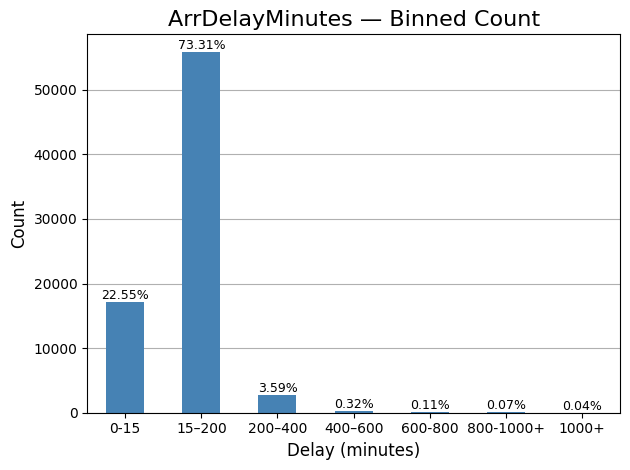

In [64]:
# Bin count of arrival delay magnitude
bins   = [0, 15, 200, 400, 600, 800, 1000, np.inf]
label = ["0-15", "15–200", "200–400", "400–600", "600-800", "800-1000+", "1000+"]

# bin the delay magnitude (right=False so 15 falls in "15–30", etc.)
delay_bins = pd.cut(reg_labels_test, bins=bins, labels=label, right=False)

bin_counts = delay_bins.value_counts().sort_index()
print(bin_counts)
print(f"\nTotal: {bin_counts.sum()}")

ax = bin_counts.plot(kind="bar", color="steelblue")
ax.set_axisbelow(True)
ax.grid(axis="y")
total = bin_counts.sum()
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f"{round(p.get_height()/total*100, 2)}%",
            ha="center", va="bottom", fontsize=9)
plt.title("ArrDelayMinutes — Binned Count", fontsize=16)
plt.xlabel("Delay (minutes)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [65]:
perf_df2 = perf_df.copy()

In [66]:
df = reg_features_test.loc[reg_features_test["ArrDelayMinutes"].between(15, 200, inclusive="left")]
print("Shape: ", df.shape, end="\n\n")

X_test = df.drop(columns=["ArrDelayMinutes"])
y_test = df["ArrDelayMinutes"].values

model_pred2 = model.predict(X_test)
perf_df2 = print_metrics(y_test, model_pred2, "15–200 min", perf_df2)

Shape:  (55792, 16)

MSE      : 291.6503450379186

RMSE     : 17.077773421553484

MAE      : 12.374600779084219

R2 Score : 0.8310622348768414



In [67]:
df = reg_features_test.loc[reg_features_test["ArrDelayMinutes"].between(200, 400, inclusive="left")]
print("Shape: ", df.shape, end="\n\n")

X_test = df.drop(columns=["ArrDelayMinutes"])
y_test = df["ArrDelayMinutes"].values

model_pred2 = model.predict(X_test)
perf_df2 = print_metrics(y_test, model_pred2, "200–400 min", perf_df2)

Shape:  (2735, 16)

MSE      : 897.9874610420475

RMSE     : 29.96643891158987

MAE      : 19.985846435100548

R2 Score : 0.658790843852403



In [68]:
df = reg_features_test.loc[reg_features_test["ArrDelayMinutes"].between(400, 600, inclusive="left")]
print("Shape: ", df.shape, end="\n\n")

X_test = df.drop(columns=["ArrDelayMinutes"])
y_test = df["ArrDelayMinutes"].values

model_pred2 = model.predict(X_test)
perf_df2 = print_metrics(y_test, model_pred2, "400-600 min", perf_df2)

Shape:  (245, 16)

MSE      : 989.5733485714285

RMSE     : 31.45748477821182

MAE      : 19.45616326530612

R2 Score : 0.68007911355167



In [69]:
df = reg_features_test.loc[reg_features_test["ArrDelayMinutes"].between(600, 800, inclusive="left")]
print("Shape: ", df.shape, end="\n\n")

X_test = df.drop(columns=["ArrDelayMinutes"])
y_test = df["ArrDelayMinutes"].values

model_pred2 = model.predict(X_test)
perf_df2 = print_metrics(y_test, model_pred2, "600–800 min", perf_df2)

Shape:  (87, 16)

MSE      : 832.4939160919542

RMSE     : 28.85297066320822

MAE      : 18.514137931034487

R2 Score : 0.7457159746583871



In [70]:
df = reg_features_test.loc[reg_features_test["ArrDelayMinutes"].between(800, 1000, inclusive="left")]
print("Shape: ", df.shape, end="\n\n")

X_test = df.drop(columns=["ArrDelayMinutes"])
y_test = df["ArrDelayMinutes"].values

model_pred2 = model.predict(X_test)
perf_df2 = print_metrics(y_test, model_pred2, "800–1000 min", perf_df2)

Shape:  (54, 16)

MSE      : 357.32886851851833

RMSE     : 18.903144408233207

MAE      : 13.579074074074073

R2 Score : 0.8781039488050404



In [71]:
df = reg_features_test.loc[reg_features_test["ArrDelayMinutes"] >= 1000]
print("Shape: ", df.shape, end="\n\n")

X_test = df.drop(columns=["ArrDelayMinutes"])
y_test = df["ArrDelayMinutes"].values

model_pred2 = model.predict(X_test)
perf_df2 = print_metrics(y_test, model_pred2, "1000+ min", perf_df2)

Shape:  (30, 16)

MSE      : 629.2228899999996

RMSE     : 25.08431561753279

MAE      : 19.506333333333313

R2 Score : 0.9867638729563143

